**Step 1 - Installation:**
This first code snipped is simply downloading all the repositories from Bitbucket and Github and installing all of the python library dependencies for them. Be aware this can take upwards of 5 minutes to execute. You should only need to run this a single time!

In [ ]:
# Check our directory just in case
%cd /content/

# Clone TTPython and Dependencies
#!rm -r ticktalkpython
!git clone https://bitbucket.org/ccsg-res/ticktalkpython.git
!cd ticktalkpython && git checkout tutorial
!cd ticktalkpython && pip install -r requirements.txt

# Clone Darknet and Dependencies
#!rm -r darknet
!git clone https://github.com/AlexeyAB/darknet/
!cd darknet/ && apt install libopencv-dev python-opencv ffmpeg
!pip install nanocamera shapely numpy sklearn matplotlib simple_pid

# Build darknet using CPU settings
!cd darknet && sed -i 's/OPENCV=0/OPENCV=1/g' Makefile
!cd darknet && sed -i 's/CUDNN=1/CUDNN=0/g' Makefile
!cd darknet && sed -i 's/GPU=1/GPU=0/g' Makefile
!cd darknet && sed -i 's/OPENMP=0/OPENMP=1/g' Makefile
!cd darknet && sed -i 's/AVX=0/AVX=1/g' Makefile
!cd darknet && sed -i 's/LIBSO=0/LIBSO=1/g' Makefile
!cd darknet && make
!chmod +x /content/darknet/libdarknet.so

# Download files from google drive for use with darknet
print(' Begining to download files... this may take a while...')

folders = ['/content/yolofiles', '/content/yolofiles/cav0', '/content/yolofiles/cav1']

files = [['/content/yolofiles/cav_test.txt', 'https://drive.google.com/u/0/uc?id=1WlL20udwRIoJq5Pkq1L6Iv6M3qhlc0MD&export=download'],
         ['/content/yolofiles/cav_train.txt', 'https://drive.google.com/u/0/uc?id=1bf0MobhUnzKnGjLdsBXGTs2vHOFIM2-w&export=download'],
         ['/content/yolofiles/cav.data', 'https://drive.google.com/u/0/uc?id=1jcEDFQ5n56Hq5tWJXXZ5N3Pg-p9qjq9t&export=download'],
         ['/content/yolofiles/cav.names', 'https://drive.google.com/u/0/uc?id=1hP7bfu5Ei-5w1cub5-vZJ-96mx0LLVMY&export=download'],
         ['/content/yolofiles/yolov4-tiny-cav.cfg', 'https://drive.google.com/u/0/uc?id=1yMQntYWsVbJ8h7x0r0Hv5y34o2IGRVJ2&export=download'],
         ['/content/yolofiles/yolov4-tiny-cav.weights', 'https://drive.google.com/u/0/uc?id=1g8r59Xcn5-n6jpc2ZjQdv-1jsLAiKN9w&export=download'],
         ['/content/yolofiles/cav0/cam_output.txt', 'https://drive.google.com/u/0/uc?id=1Vt5BEkVysTk5dJE0Lb47EQttT46LVB97&export=download'],
         ['/content/yolofiles/cav0/lidar_output.txt', 'https://drive.google.com/u/0/uc?id=1fTYHu3lmEIVjul30EfUyGWyvifPSSAQY&export=download'],
         ['/content/yolofiles/cav0/live_test_output.avi', 'https://drive.google.com/u/0/uc?id=1mqnQVoy8ZH2jDLZehC_J2ihtMcBfnse-&export=download'],
         ['/content/yolofiles/cav1/cam_output.txt', 'https://drive.google.com/u/0/uc?id=1xHz5YmlhRC0ex8PSE5IKB8ZA6DBaakDk&export=download'],
         ['/content/yolofiles/cav1/lidar_output.txt', 'https://drive.google.com/u/0/uc?id=1uYCHBluYurS4GGLSgPRpDsMWAY6GCaGb&export=download'],
         ['/content/yolofiles/cav1/live_test_output.avi', 'https://drive.google.com/u/0/uc?id=1kJnRCRyXbBuwu8RojMJgQy1PEngGmuXc&export=download']]


import os.path
import gdown

# Check that the folders exist or create them
for folder in folders:
  if not os.path.exists(folder):
    os.makedirs(folder)

# Check that the files exist or download them
for file in files:
  if os.path.isfile(file[0]): 
    print("File " +  file[0] + " found.")
  else:
    print("Downloading file " +  file[0] + ".")
    gdown.download(file[1], file[0], quiet=False)

# Fix a few lines in cav.data
!cd /content/yolofiles && sed -i 's/data\//\/content\/yolofiles\//g' cav.data

# Wait for a second for gdown to finish
import time
time.sleep(1)

# Check if we are done, sometime google drive doesn't download the AVI files and it must be done manually!
all_is_good = True
print("\n\nTTPython setup is checking that all files downloaded correctly....\n")
for file in files:
  if not os.path.isfile(file[0]): 
    print("File " +  file[0] + " not found. Please download from ", file[1] ," and upload to the following location using the files menu on the left ", file[0])
    all_is_good = False
if all_is_good:
  print("TTPython setup complete, proceed to next block.")
else:
  print("\n!!!TTPython setup did not prpoerly download (a) file(s), please follow the above steps!!!")

**Step 2 - Compile Example 1 in Ticktalk:** Here we will compile example 1 in Ticktalk. Run this cell block and you should see the graph of SQs shown as output. 

*Note: Before running this please make sure the last step of the intallation instructions above did not return an error - sometimes the .avi files do not properly download from google drive.*

[Errno 2] No such file or directory: '/content/ticktalkpython/'
/home/kyle/ttpython
Running example_1_camera_sq
Compiling example_1_camera_sq
Compiling example_1_camera_sq


TTPython.CompilerRules:DEBUG:: *** function: camera_sampler
TTPython.CompilerRules:DEBUG:: *** decorator: SQify
TTPython.CompilerRules:DEBUG:: *** function: process_camera
TTPython.CompilerRules:DEBUG:: *** decorator: SQify
TTPython.CompilerRules:DEBUG:: *** function: write_to_file
TTPython.CompilerRules:DEBUG:: *** decorator: SQify
TTPython.CompilerRules:DEBUG:: *** function: example_1_test
TTPython.CompilerRules:DEBUG:: *** decorator: GRAPHify
TTPython.CompilerRules:DEBUG:: Child of functionDef visit: <_ast.Assign object at 0x7ff12b4d1b50>
TTPython.SQ:DEBUG:: execution kwargs: {}
TTPython.SQSync:DEBUG:: Create port for index 0 as type TTPortType.Vanilla
TTPython.CompilerRules:DEBUG:: Child of functionDef visit: <_ast.Assign object at 0x7ff12b4d1d60>
TTPython.SQ:DEBUG:: execution kwargs: {}
TTPython.SQSync:DEBUG:: Create port for index 0 as type TTPortType.Vanilla
TTPython.CompilerRules:DEBUG:: Child of functionDef visit: <_ast.Assign object at 0x7ff12b4d1a00>
TTPython.SQ:DEBUG:: exec

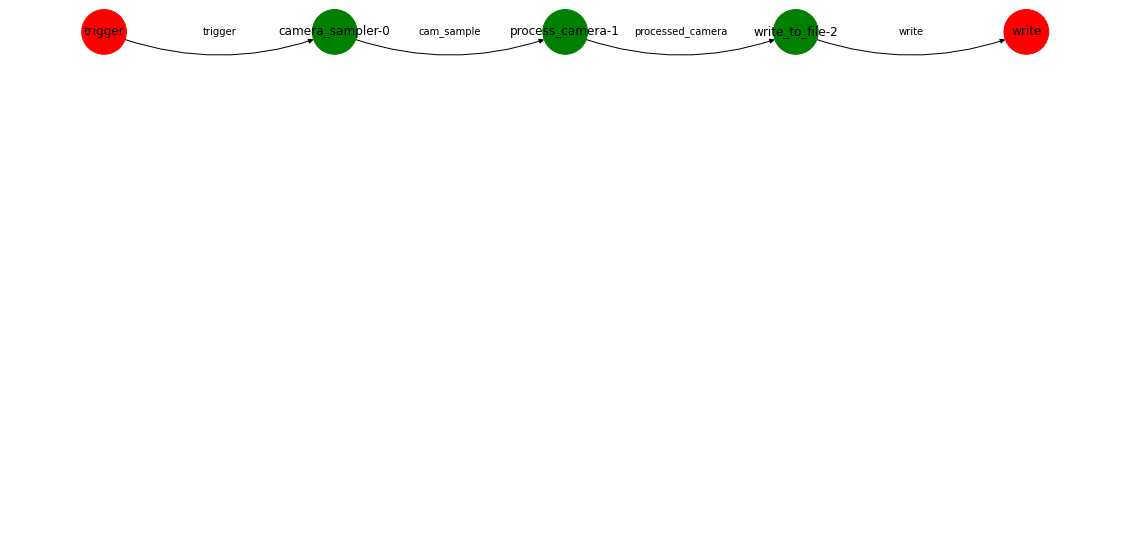

In [3]:
# Check our directory just in case
%cd /content/ticktalkpython/

from tests.test import all_tests
from tt.Compiler import TTCompile

test_name = "example_1_camera_sq"
print(f"Running {test_name}")
exec(f"import examples.{test_name}")

print(f"Compiling {test_name}")
compile_arg = f"examples/{test_name}.py"
%run compile.py $compile_arg

**Step 3 - Run Example 1 in Ticktalk:**
Now that we have compiled example 1 within Ticktalk, lets run the code and see how it goes. Example 1 will spin up a streamify node that reads from a pre-recorded camera stream. This will then be sent to another SQ that will process the camera frames using a darknet based convolutional neural net called YoloV4. Finally the output of each detection frame (CAV locations in in x,y coordinates) will be written to a file in the output folder. 

*Note: If this step results in an error check that the intallation instructions did not return an error in the last print statement - sometimes the .avi files do not properly download from google drive and must be done manually.*

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

# Run the streaming_merge graph that should have been compiled and saved in the previous block. This will fail if that has not been run yet. Note that jupyter is MUCH slower than running the same code from the terminal (2-3 orders of magnitude)
import tt.DebugLogger as log
import logging
log.set_base_logger_level(logging.ERROR)
from tests.test import all_tests

import tests.stream_merge_test as stm
log.set_base_logger_level(logging.ERROR)

test_name = "example_1_camera_sq"
simulate_arg = f"./output/{test_name}.pickle"
%run simulate.py $simulate_arg

**Step 4 - Compile Example 2 in Ticktalk:**
 Here we will compile example 2 in Ticktalk. Run this cell block and you should see the graph of SQs shown as output. This step is similar to step 3 but we have changed the program to example 2.

In [4]:
# Check our directory just in case
%cd /content/ticktalkpython/

from tests.test import all_tests
from tt.Compiler import TTCompile

test_name = "example_2_camera_lidar_fusion_stream"
print(f"Running {test_name}")
exec(f"import examples.{test_name}")

print(f"Compiling {test_name}")
compile_arg = f"examples/{test_name}.py"
%run compile.py $compile_arg


[Errno 2] No such file or directory: '/content/ticktalkpython/'
/home/kyle/ttpython
Running example_2_camera_lidar_fusion_stream


ModuleNotFoundError: No module named 'shapely'

**Step 5 - Run Example 2 in Ticktalk:**
Now that we have compiled example 2 within Ticktalk, lets run the code and see how it goes. Example 2 will spin up two different streamify nodes, one similar to example 1 that reads from a pre-recorded camera stream. This will then be sent to another SQ that will process the camera frames using a darknet based convolutional neural net called YoloV4. The second streamify node is opening frames from a recording of a LIDAR mounted next to the camera from example 1. This will be sent to another SQ that qill cluster the points seen by the lidar and then take the centroid of the clusters. Finally the output of both of these recognition pipelines (CAV locations in in x,y coordinates) will be ingested by a final SQ that will perform a sensor fusion on the matching frames and then writes the results to an output file. We will visualize the contents of this output file in the next step.

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

# Run the graph that should have been compiled and saved in the previous block. This will fail if that has not been run yet. Note that jupyter is MUCH slower than running the same code from the terminal (2-3 orders of magnitude)
import tt.DebugLogger as log
import logging
log.set_base_logger_level(logging.ERROR)
from tests.test import all_tests

import tests.stream_merge_test as stm
log.set_base_logger_level(logging.ERROR)

test_name = "example_2_camera_lidar_fusion_stream"
simulate_arg = f"./output/{test_name}.pickle"
%run simulate.py $simulate_arg --timeout 10000000000

**Step 6 - Display Example 2 Data:**
The data from example 1 was fairly easy to look at as there was only a single other vehicle in the scene that it was detecting. However example 2 has many more detections from the LIDAR. Therefore we have created a display function that reads in the output from example 2 and will display it on a 2D graph.

In [ ]:
import matplotlib.pyplot as plt
import json

# define an empty list
data = []

# open file and read the content in a list
with open('/content/ticktalkpython/output/example_2_output.txt', 'r') as filehandle:
    for line in filehandle:
        # remove linebreak which is the last character of the string
        currentData = line[:-1]

        # add item to the list
        data.append(json.loads(currentData))

x = []
y = []
for frame in data:
  for item in frame:
    x.append(item[0])
    y.append(item[1])

plt.plot(x, y, 'o', color='black');
plt.show()

**Step 7 - Compile and Run Example 2 in Ticktalk w/ Non-Achievable Timing:**

*Part 1:* Lets go into the source code and try to change some timing parameters for TTPython. The first one we should change is TTPeriod. This construct dictates the period at which our streams will send new data. In the original example 2 this was set to 750000 or 750ms. This is because in the free tier of Google Colab the entire recognition pipeline takes about 700ms to execute so we add a little extra space to make sure that it always has enough processing time. Go change this number to something else like TTPeriod=250000. After you change this value in examples/example_2_camera_lidar_fusion_stream.py, run the following step to check the results. The telltale sign of a deadline that is too short will be that the sensor fusion SQ will not be firing when you set the log level to WARN. This is because if either the LIDAR or CAMERA don't arrive within the time window then the Local Fusion SQ will not fire as often. A telltale sign of a deadline that is too long will be too much extra wait time between the SQ that writes to the file and the next subsequent streamify node firing. This again is visible if the log level is set to Warn so that the SQ firings are shown in the console output.
 
*Part 2:* Next we should take a look at another construct, TTDataIntervalWidth. This specifies the time range at which TTPython will match the outputs of two streams and consider them to be match-able. In this example our default value is TTDataIntervalWidth=250000 or 250ms because +-250ms is enough range that the LIDAR and Camera streams will be properly matched even taking into account that LIDAR recognition and Camera recognition must run before the matching stage. Lets make this not work then, because camera recognition takes around 300ms on Google collab using an interval width like TTDataIntervalWidth=125000 should cause none of our streams to match, and thus will not allow the local_fusion node to fire! Conversely if the TTDataIntervalWidth is too large then steams with timesteps that are very far apart may be matched. This is very hard to see in this example as we do not specifically print the timestamps of the data that was matched but some simple changes to the code in the sensor fusion SQ could do it. Make sure to change TTPeriod back to 750000 before messing with the TTDataIntervalWidth so we are only testing one construct at a time.
 
*Part 3:* Now it is your turn to go crazy and try combinations of TTPeriod and TTDataIntervalWidth to see what happens. Try answering the following questions:
 
1.   What is the smallest you can make TTDataIntervalWidth and the application still works? The application still working is defined as the sensor fusion node firing when you have the logging level set to warn because if the interval is too small the streams will not be matched and therefore the sensor fusion wont fire.
2.   What is the smallest you can make TTPeriod and the application still works? Is there a number where it works sometimes but not all the time - i.e. you are within the timing "jitter" zone? This zone will be an area where sometimes the write to file SQ fires and sometimes it does not, which should be visible with logging set to warn.
 
When you are done answering these questions, just make sure to change the values back to the default values of TTDataIntervalWidth=250000 and TTPeriod=750000.


In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

from tests.test import all_tests
from tt.Compiler import TTCompile

test_name = "example_2_camera_lidar_fusion_stream"
print(f"Running {test_name}")
exec(f"import examples.{test_name}")

print(f"Compiling {test_name}")
compile_arg = f"examples/{test_name}.py"
%run compile.py $compile_arg

# Check our directory just in case
%cd /content/ticktalkpython/

# Run the streaming_merge graph that should have been compiled and saved in the previous block. This will fail if that has not been run yet. Note that jupyter is MUCH slower than running the same code from the terminal (2-3 orders of magnitude)
import tt.DebugLogger as log
import logging
log.set_base_logger_level(logging.ERROR)
from tests.test import all_tests

import tests.stream_merge_test as stm
log.set_base_logger_level(logging.ERROR)

# Remove our old output file
!rm /content/ticktalkpython/output/example_2_output.txt

simulate_arg = f"./output/{test_name}.pickle"
%run simulate.py $simulate_arg --timeout 10000000000

**Step 8 - Compile Example 3 in Ticktalk:**
 Here we will compile example 3 in Ticktalk. Run this cell block and you should see the graph of SQs shown as output. This step is similar to step 5 but we have changed the program to example 3. Example 3 adds in the global fusion steps as well as ensemble construct which explained better in step 9.

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

from tests.test import all_tests
from tt.Compiler import TTCompile

test_name = "example_3_two_cavs_fusion_stream"
print(f"Running {test_name}")
exec(f"import examples.{test_name}")

print(f"Compiling {test_name}")
compile_arg = f"examples/{test_name}.py"
%run compile.py $compile_arg

**Step 9 - Run Example 3 in Ticktalk:**
Now that we have compiled example 3 within Ticktalk, lets run the code and see how it goes. Example 3 will use same code from example 2, but will create 2 copies of it that read in from different data files. After the local fusion is done (same as example 2) the output from each CAV is sent to the global fusion function (which is just a wrapper for a second call of local fusion) where it is fused together to get a global picture of what is going on. You may also notice some new concepts are introduced here - ensembles. Using similar syntax to the Python "with" construct we can designate sections of code to will be deployed to specifically names ensembles - such as "CAV0", "CAV1" and "RSU" in this example.

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

# Run the streaming_merge graph that should have been compiled and saved in the previous block. This will fail if that has not been run yet. Note that jupyter is MUCH slower than running the same code from the terminal (2-3 orders of magnitude)

import tt.DebugLogger as log
import logging
log.set_base_logger_level(logging.ERROR)
from tests.test import all_tests

import tests.stream_merge_test as stm
log.set_base_logger_level(logging.ERROR)

test_name = "example_3_two_cavs_fusion_stream"
simulate_arg = f"./output/{test_name}.pickle"
%run simulate.py $simulate_arg --timeout 10000000000

**Step 10 - Compile Example 4 in Ticktalk:**
 Here we will compile example 4 in Ticktalk. Run this cell block and you should see the graph of SQs shown as output. This step is similar to step 8 but we have changed the program to example 4. Example 4 adds in the PlanB deadline construct.

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

from tests.test import all_tests
from tt.Compiler import TTCompile

test_name = "example_4_two_cavs_fusion_stream_deadline_ensemble"
print(f"Running {test_name}")
exec(f"import examples.{test_name}")

print(f"Compiling {test_name}")
compile_arg = f"examples/{test_name}.py"
%run compile.py $compile_arg

**Step 11 - Run Example 4 in Ticktalk:**
Now that we have compiled example 4 within Ticktalk, lets run the code and see how it goes. Example 4 seems almost identical to example 3. However one major thing has changed - we have added deadlines. Actual Cyber Physical Systems don't always meet their deadlines - many times due to uncontrollable external variables like network speed or sensor failure. When that happens we need a mechanism to make sure that time critical SQs still get executed and that appropriate action can be taken to mitigate damage. In the case of driving a CAV this could mean an emergency stopping maneuver. In the case of our application we have been working on, we have multiple inputs to the global fusion and we want to make sure it still runs even when one or even both of the locally fused CAV sensor data does not arrive in time. To do this we add in the TTPython PlanB deadline construct to detect the missed deadline and create a new array that is empty to send in its place. The global fusion application knows how to handle empty arrays and it will use all available data from other vehicles as well as the Kalman filter predictions to create a best answer for where all objects are until hopefully the next iteration when the deadline is met again. TTPython also allows for a deadline to stop the subsequent SQ from firing as well using the TTContinue clause but setting it to false.

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

# Run the streaming_merge graph that should have been compiled and saved in the previous block. This will fail if that has not been run yet. Note that jupyter is MUCH slower than running the same code from the terminal (2-3 orders of magnitude)

import tt.DebugLogger as log
import logging
log.set_base_logger_level(logging.ERROR)
from tests.test import all_tests

import tests.stream_merge_test as stm
log.set_base_logger_level(logging.ERROR)

test_name = "example_4_two_cavs_fusion_stream_deadline_ensemble"
simulate_arg = f"./output/{test_name}.pickle"
%run simulate.py $simulate_arg --timeout 10000000000

**Step 12: Test the Plan Be Deadline Construct**
Let us purposefully introduce some errors into the streams of example 4 so that we can test out the deadline construct. In order to do this we will be using a TTPython testing construct that allows us to note send a token. We will then selectively not send a token from CAV1 every 4th time the local sensor fusion is called on CAV1. This would simulate a connection link going down or being too slow resulting in the need to fire the global fusion without the data. Due to some slowdowns we have simulating all aspects of this demo on Google Colab this plan B deadline fires every 10 seconds but in the real CAVs it would be set to 100 milliseconds after the streamify nodes fire. What we should see if the log level is set to Warn is that the global fusion node will fire and we will get an output in the example_4_output.txt file for each iteration despite the fact CAV1 will not send any results every 4th iteration. Our global fusion will receive an empty array from PlanB for CAV1 and the Kalman filter will run without input for many of the tracked objects. However the Kalman filter is set up to keep tracking objects until it does not see them for at least 4 iterations so what will happen is that we will get a predicted output from the global fusion for these select tracks for the specific iteration that the CAV1 does not send any output. However the next data frame CAV1 will send data as usual and as long as the prediction was not too far off the matching step will still be able to associate it with the correct data from CAV1 and the Kalman Filter will continue almost as if nothing had happened. This is a very important feature for real time cyber-physical systems with slow communication or other problems where missing data is not uncommon so we must operate on what data we have. 

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

from tests.test import all_tests
from tt.Compiler import TTCompile

test_name = "example_4_two_cavs_fusion_stream_deadline_ensemble_test"
print(f"Running {test_name}")
exec(f"import examples.{test_name}")

print(f"Compiling {test_name}")
compile_arg = f"examples/{test_name}.py"
%run compile.py $compile_arg

# Check our directory just in case
%cd /content/ticktalkpython/

# Run the streaming_merge graph that should have been compiled and saved in the previous block. This will fail if that has not been run yet. Note that jupyter is MUCH slower than running the same code from the terminal (2-3 orders of magnitude)
import tt.DebugLogger as log
import logging
log.set_base_logger_level(logging.ERROR)
from tests.test import all_tests

import tests.stream_merge_test as stm
log.set_base_logger_level(logging.ERROR)

# Remove our old output file
!rm /content/ticktalkpython/output/example_4_output.txt

simulate_arg = f"./output/{test_name}.pickle"
%run simulate.py $simulate_arg --timeout 10000000000

**End of Beginner Section:**
If you have made it to this point then it is safe to consider yourself a beginer user of TTPython, congradulations! The following steps in the tutorial get progressivly harder and involve conversion of vanilla Python coder over to TTPython should you choose to accept the challenge but with it comes with the ability to graduate to intermediate or even expert TTPython user.

**Step 12: (Intermediate) Convert Example 1 from Non-TTPython to TTPython:**
Here is the code for example 1 but not using the TTPython constructs. It is worth mentioning this will not work exactly the same as the TTPython version as many of the timing guarantees are not present here - nor is the example automatically threaded like TTPython is. Your task here, should you choose to accept it will help you solidify all the TTPython concepts you learned today. Try running this example code. After that, open up the source code and try to convert it to TTPython. If you can complete this task for this simple application you can move onto the next example which is more complex.

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

# non tt-python version
!cd examples/ && python streamify_camera_darknet_non_tt.py

**Step 13: (Advanced) Converting Example 2 Non-TTPython to TTPython:**
Similar to step 12, we are once again giving you the code for a regular python version of example 2. It has more streamify nodes and starts to introduce the concepts of merging streams and data interval validity. If you can convert this example over and get it to run similarly to the python version it is safe to say you are now an Advanced TTPython user!

In [ ]:
# Check our directory just in case
%cd /content/ticktalkpython/

# non tt-python version
!python examples/streamify_camera_lidar_non_tt.py

**Step 14: (Expert) The Grande Finale - Use Example 2 Python Code to Create Examples 3 and 4:** TTPython is very versatile. In the previous steps 11 and 12 we gave you non-TTPython code to convert over. To get to Example 3 and 4 doesn't require any additional code. What it does require is properly creating duplicate versions of that code to create a second CAV as well as the RSU which is calling the same local sensor fusion algorithm again to get the global fusion. To get to the examples 3 you must properly declare ensembles and multiple copies of the code that you created in example 2. And finally to get to example 4 you need to surround the global fusion inputs with the PlanB deadline construct and set the timing of that correctly. If you can accomplish all of this you can officially call yourself a TTPython Expert user!